# Adding a new scheme

A **scheme** owns the *iteration policy*: how many steps to take, whether to
accept or reject one, how to damp, and when to stop. The per-iteration
mathematics belongs to the analysis instead — see
[Adding a new analysis](adding_an_analysis.ipynb).

Roughly:

| | owns |
| --- | --- |
| analysis | one step: ensemble + predictions -> update |
| scheme | the loop around it: accept/reject, damping, stopping |
| ensemble | the data: state realisations, observations, simulator |

## What you inherit

Concrete schemes subclass `AssimilationScheme`, which combines the algorithm
core with the run workflow (artifact saving, diagnostics, outlier handling):

In [1]:
from pipt.update_schemes.core.workflow import AssimilationScheme

for c in AssimilationScheme.__mro__:
    print("   ", c.__name__)

    AssimilationScheme
    AssimilationWorkflowMixin
    AssimilationSchemeBase
    AnalysisBindingMixin
    RestartMixin
    ABC
    object


That single base gives you the iteration loop, convergence bookkeeping,
restart handling, the result object, analysis binding, and the ensemble
façade. The order matters and is easy to get wrong by hand, which is why the
combination is made once here rather than in every scheme.

## What the base calls, and when

`run_assimilation()` drives this sequence. Everything marked **▸** is yours to
override; the base supplies a do-nothing default for each, so you override only
what you need.

```
run_assimilation()
│
├─ run_prior_forecast()             forecast the prior ensemble
│    └─ after_forecast(state)     ▸ may resample members; returns state
├─ score_prior()                  ▸ misfit of the prior
├─ after_prior_forecast()         ▸ once, after the prior is scored
│
├─ while iteration < maxiter:
│    ├─ update_step()             ▸ REQUIRED — returns a StepReport
│    ├─ after_accepted_iteration()▸ only when that attempt was accepted
│    ├─ check_misfit_convergence()  generic; on unless misfit_tol = 0
│    ├─ check_state_convergence()   generic; on unless step_tol   = 0
│    └─ check_convergence()       ▸ your own stopping criterion
│
└─ after_loop(converged)          ▸ once, before the result is assembled
```

The two generic criteria are **on by default** (`misfit_tol=0.01`,
`step_tol=1e-8`). Every shipped scheme passes `0.0` for both, because it
decides for itself in `check_convergence()` — do the same unless you want
them, or a scheme that merely stops moving the state will report itself
converged.

`update_step()` is the only one you must write. It returns a `StepReport`;
set `accepted=False` to reject an attempt, and the loop retries at the same
iteration number instead of advancing — how the Levenberg-Marquardt family
backs off.

If you stop on your own criterion, set `self.conv_msg` when you do — the two
generic checks set it themselves, but yours is the only thing that can explain
your own stop, and a run that ends without one reports no stopping reason.

### What is *not* on that list

There is no `after_analysis` hook on the base. That point exists only *inside*
`update_step()`, and the base does not dictate the shape of your step — it
calls `update_step()` and nothing within it. `AssimilationWorkflowMixin`
declares and implements one for schemes that inherit `AssimilationScheme`, and
the scheme calls it from its own step, as the example below does.

## What `update_step()` must report

The base does not inspect *how* you take a step, but it needs to know what the
step produced. That is the return value:

```python
@dataclass(slots=True)
class StepReport:
    accepted: bool                    # keep this step, or retry?
    state:    Any                     # the state this attempt produced
    misfit:   np.ndarray              # per-realisation data misfit, as of now
    why_stop: dict | None = None      # merged into result.why_stop
```

The three required fields are positional, so leaving one out is a `TypeError`
where you wrote it — not a `None` surfacing three iterations later. The loop
commits `state` when `accepted`, and discards it otherwise.

The loop derives the scalars from the one array:

```python
self.ensemble_misfit  = misfit
self.data_misfit_mean = float(misfit.mean())
self.data_misfit_std  = float(misfit.std())
```

so those three can no longer drift apart, which they could when each scheme
assigned them separately.

**"As of now" is deliberate.** A scheme that rejects a step reports the misfit
it wants the loop to record — for LM-EnRML that is the *last accepted* one,
restored when it backs off, because that is what the next comparison is
against.

### Still yours to do

| do | why |
| --- | --- |
| `self.prev_data_misfit_mean = self.data_misfit_mean` before reporting | the relative-change test compares against it |
| `self.prior_data_misfit_mean`, once | the result reports it; `score_prior()` is the natural place |
| pass the trial state to `self.run_forecast(state)` | it returns the state actually forecast |
| call `self.after_analysis()` | the workflow hook between analysis and forecast |

```python
enX_trial = self.enX + step               # a local value; nothing is parked
enX_trial = self.run_forecast(enX_trial)  # may come back with members resampled
return StepReport(accepted=True, state=enX_trial, misfit=misfit)
```

You do **not** commit the state, or set `self.step_accepted`,
`self.data_misfit_mean`, `self.data_misfit_std` or `self.ensemble_misfit`.
The loop does all of that from the report, committing `state` when
`accepted` and discarding it otherwise. The trial state never touches the
ensemble at all — it is a local value you pass to `run_forecast` and hand
back in the report.

**Score the prior in `score_prior()`, not in `update_step()`.** The base calls
it after the prior forecast and before the loop, so it sees the prior
ensemble. Scoring it on the first pass through `update_step` instead records
the misfit *after one step* and labels it the prior.

## The façade rule

Reads of ensemble state go through the scheme; **writes go to the ensemble
explicitly**:

```python
x = self.enX                       # read  -- a property on the scheme
self.ensemble.list_states = [...]  # write -- explicit, via the ensemble
```

A read-only property has no setter, so a stray `self.enX = ...` raises rather
than silently creating a copy the forecast never sees.

The state you are *working on* is not written to the ensemble at all. A trial
state stays a local value: you pass it to `run_forecast` and return it in the
`StepReport`, and the loop commits it to `ensemble.enX` if the step was
accepted. Four names are the
exception and *do* have setters, because a scheme may legitimately compute
them itself: `cov_data`, `scale_data`, `proj`, `Am`.

## A worked example

A smoother that takes a fixed fraction of each analysis step and never
rejects — simpler than LM-EnRML, but a complete scheme.

In [2]:
from copy import deepcopy
import numpy as np
import pipt.misc_tools.analysis_tools as at
from geostat.decomp import Cholesky
from pipt.ensembles import AssimilationEnsemble
from pipt.update_schemes.core.workflow import AssimilationScheme
from pipt.update_schemes.analysis.approx import approx_update
from pipt.update_schemes.core.scheme_base import StepReport


class FixedStepSmoother(AssimilationScheme):
    """Iterative smoother taking a fixed fraction of each analysis step."""

    ENSEMBLE_CLASS = AssimilationEnsemble
    COMPATIBLE_ANALYSES = {"approx": approx_update}

    def __init__(self, keys_da, keys_en, sim, analysis=None):

        # Initialize the ensemble class
        ensemble = self.ENSEMBLE_CLASS(keys_da, keys_en, sim)

        # Initialize the base class
        super().__init__(
            ensemble, 
            misfit_tol=0.0, # zero tolerances switch off generic criteria
            step_tol=0.0    # zero tolerances switch off generic criteria
        )

        # Set up the analysis method for this scheme (will be approx_update)
        self.bind_analysis(self.resolve_analysis(analysis, keys_da))

        # Set up the scheme-specific parameters
        opts = self.keys_da.get("iteration", {})
        self.maxiter      = opts.get("max_iter", 5)
        self.gamma        = opts.get("gamma", 0.5)   # fixed step length
        self.lam          = 0.0   # no damping -- but the analysis reads it
        self.trunc_energy = self.keys_da.get("energy", 0.98)
        self.iteration    = self.ensemble.iteration = 0
        self.prev_data_misfit_mean = None

        # The ensemble does not build these; the scheme owns them.
        self.ensemble.prior_enX      = deepcopy(self.enX)
        self.ensemble.list_states    = list(self.enX.indices)
        self.ensemble.list_datatypes = self.keys_da["datatype"]
        self.vecObs = self.data_df.to_matrix()
        self.enObs = self.ensemble.perturb_observations(self.vecObs)
        self.cov_data = at.construct_data_cov(self.data_var_df)

    def score_prior(self):
        """Score the prior forecast. The base calls this before the loop."""
        misfit = at.calc_objectivefun(
            self.enObs, self.pred_data.to_matrix(), self.cov_data
        )
        self.ensemble_misfit = misfit
        self.prior_data_misfit_mean = float(np.mean(misfit))
        self.data_misfit_mean = self.prior_data_misfit_mean
        self.data_misfit_std = float(np.std(misfit))

    def update_step(self) -> StepReport:
        # Prediction ensemble matrix
        self.enPred = self.pred_data.to_matrix()

        # Calulate step
        step = self.update(
            enX=self.enX, 
            enY=self.enPred, 
            enE=self.enObs
        )

        # A local proposal -- nothing is written to the ensemble until the
        # loop commits what we report.
        enX_trial = self.enX + self.gamma * step
        self.after_analysis()

        # Forecast it. run_forecast hands back the state actually used (can be resampled by outlier replacement).
        enX_trial = self.run_forecast(enX_trial)

        # Score the forecast
        self.prev_data_misfit_mean = self.data_misfit_mean
        data_misfit = at.calc_objectivefun(
            self.enObs, self.pred_data.to_matrix(), self.cov_data
        )

        return StepReport(
            accepted=True, 
            state=enX_trial,
            misfit=data_misfit
        )


    def score_prior(self):
        """Score the prior forecast. The base calls this before the loop,
        which is why the prior misfit is the *prior's* -- scoring it inside
        update_step would record the misfit after the first step instead.
        """
        misfit = at.calc_objectivefun(
            self.enObs, self.pred_data.to_matrix(), self.cov_data
        )
        self.ensemble_misfit = misfit
        self.prior_data_misfit_mean = float(np.mean(misfit))
        self.data_misfit_mean = self.prior_data_misfit_mean
        self.data_misfit_std = float(np.std(misfit))

    def check_convergence(self) -> bool:
        return False  # Run the full schedule (all iterations)

print("defined", FixedStepSmoother.__name__)

defined FixedStepSmoother


## A case to run it on

In [3]:
import os, tempfile
from copy import deepcopy
import numpy as np
from misc.structures import PETDataFrame
from simulator.simple_models import lin_1d

# A 60-cell state observed at every 5th position. Pure numpy, runs instantly.
STATE_SIZE = 60
CFG_SIM = {"reporttype": "position", "reportpoint": list(range(5, STATE_SIZE, 5)),
           "datatype": ["value"],
           # NOTE: >1 is deliberate. lin_1d returns a shared internal object from
           # run_fwd_sim, so a sequential run aliases every member onto the same
           # prediction and the ensemble collapses to zero spread.
           "parallel": 4}

CFG_ENS = {"ne": 50, "state": "x",
           "prior_x": {"vario": "sph", "mean": [0.0] * STATE_SIZE, "var": 1.0,
                       "range": 20.0, "aniso": 1.0, "angle": 0.0,
                       "grid": [STATE_SIZE, 1]}}

def cfg_da(analysis, **iteration):
    # Only what FixedStepSmoother actually reads. The Levenberg-Marquardt
    # keys (lambda, lambda_factor, ...) belong to schemes that damp; this one
    # takes a fixed fraction of each step instead.
    it = {"max_iter": 20, "gamma": 0.5}
    it.update(iteration)
    return {"scheme": "custom", "analysis": analysis, "energy": 0.95,
            "obsname": "position", "data": "true_data.pkl", "datavar": "var.pkl",
            "iteration": it}

def make_truth():
    """Write the synthetic observations the schemes below assimilate.

    Returns the true state, so the plots can compare against it.
    """
    np.random.seed(10)
    sim = lin_1d(CFG_SIM); sim.setup_fwd_run()
    state = {"x": np.random.multivariate_normal(np.zeros(STATE_SIZE), np.eye(STATE_SIZE))}
    pred = PETDataFrame.from_records(sim.run_fwd_sim(state, 0), index=CFG_SIM["reportpoint"])
    data, var = pred.copy(), pred.copy()
    for c in data.columns:
        data[c] = data[c].apply(np.squeeze)
        var[c] = var[c].apply(lambda _: ["abs", 1.0])
    data.to_pickle("true_data.pkl"); var.to_pickle("var.pkl")
    return state["x"]

os.chdir(tempfile.mkdtemp())   # keep run artifacts out of the docs tree
TRUE_STATE = make_truth()
OBS_AT = CFG_SIM["reportpoint"]
print(f"case ready: {STATE_SIZE}-cell state, {len(OBS_AT)} observations, ne={CFG_ENS['ne']}")

case ready: 60-cell state, 11 observations, ne=50


In [4]:
np.random.seed(10)
res = FixedStepSmoother.assimilate(cfg_da("approx"), deepcopy(CFG_ENS),
                                   lin_1d(CFG_SIM), analysis="approx")
print(f"misfit {res.prior_data_misfit:7.2f} -> {res.data_misfit:6.2f}"
      f"   iterations={res.nit}")
print("stopped because:", res.message)

2026-08-24│14:50:44 :  =========== Running Data Assimilation - CUSTOM ===========


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

...

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-24│14:50:46 : Maximum iterations reached without convergence.


2026-08-24│14:50:46 :  
 Convergence was met. Obj. function reduced from 30.0 to 6.2


2026-08-24│14:50:46 :  Assimilation finished after 20 iteration(s): Maximum number of iterations reached


misfit   29.98 ->   6.24   iterations=20
stopped because: Maximum number of iterations reached


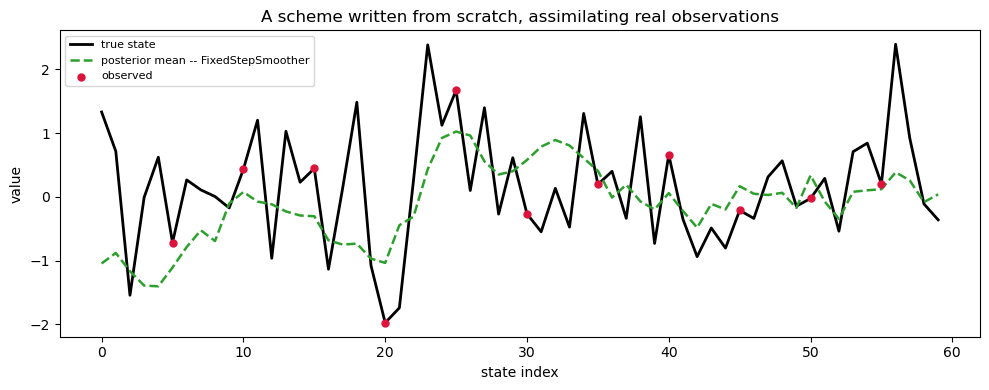

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(TRUE_STATE, "k-", lw=2, label="true state")
ax.plot(np.asarray(res.x).mean(axis=-1), "--", lw=1.8, c="tab:green",
        label="posterior mean -- FixedStepSmoother")
ax.scatter(OBS_AT, TRUE_STATE[OBS_AT], c="crimson", zorder=5, s=25, label="observed")
ax.set_xlabel("state index"); ax.set_ylabel("value")
ax.set_title("A scheme written from scratch, assimilating real observations")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Making it available from a config

The class works directly, as above. To reach it the way the built-in schemes
are reached — by name from a config's `scheme` / `analysis` keys — register
the combination:

In [6]:
from pipt.update_schemes import registry

registry.register_scheme("fixedstep", "approx", FixedStepSmoother, overwrite=True)

ctor = registry.get_scheme("fixedstep", "approx")
print("registry resolves to:", ctor.func.__name__ if hasattr(ctor, "func") else ctor)
print("('fixedstep', 'approx') in available_schemes():",
      ("fixedstep", "approx") in registry.available_schemes())

registry resolves to: <class '__main__.FixedStepSmoother'>
('fixedstep', 'approx') in available_schemes(): True


## Checklist

1. Subclass `AssimilationScheme`.
2. Set `ENSEMBLE_CLASS` and `COMPATIBLE_ANALYSES`.
3. In `__init__`: build the ensemble, call `super().__init__(...)`, then
   `bind_analysis(resolve_analysis(...))`. Set anything the analyses expect
   (`lam`, `trunc_energy`) and anything the ensemble does not build for you
   (`cov_data`, the observation vector).
4. Implement `update_step()`; return `False` for a rejected attempt.
5. Read state through the scheme, write it through `self.ensemble`.
6. Override `check_convergence()` if the scheme stops on its own criterion,
   and set `self.conv_msg` when it does — otherwise the run reports no
   stopping reason.
7. `register_scheme(...)` if it should be reachable from a config.